## Домашка 1
#### *«Великаны — как луковицы. Лук многослоен! Я тоже! Слой за слоем. Ты усёк? Мы многослойные!» — Шрек*

Эта домашка про декомпозицию и срезы. За неё можно получить максимум 6 баллов. 

**Дедлайны**  
Мягкий дедлайн: 20.09.2026 23:59 по МСК.   
Жесткий дедлайн: 27.09.2026 23:59 по МСК.  

Штраф за сдачу после мягкого дедлайна: –20% от набранного балла.   
После жесткого дедлайна работы не принимаются.   

**Правила сдачи**   
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.    

**Использование ИИ**
- Использование генеративных моделей для написания кода допустимо при следующих условиях: сгенерированный фрагмент прочитан, адаптирован под условие задачи и данные, вы способны объяснить каждую его строку. Решение, полученное путем передачи модели формулировки задания целиком и прямого копирования ответа в ячейку ноутбука без содержательной переработки, оценивается в 0 баллов за это задание.
- Ответы на текстовые вопросы (описание поведения графика, интерпретация метрики, формулировка гипотез и т.п.) должны быть написаны вами самостоятельно в markdown-ячейках. Использование генеративных моделей для ответа на текстовые вопросы приводит к аннулированию всей работы, а не отдельного задания: интерпретация результатов — главный проверяемый в курсе навык, передача ее ИИ лишает нас возможности оценить, насколько хорошо вы усвоили материал.
- Если генеративная модель использовалась при решении, в конце ноутбука в отдельной markdown-ячейке укажите: номера заданий, при работе над которыми она применялась, использованную модель (с версией) и текст промтов. При обоснованном подозрении на использование ИИ, не отраженное в этом разделе, работа аннулируется целиком независимо от того, к какой части заданий относится подозрение.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета. 
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в ведомости на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_1). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3. 

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.

Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_1_data.zip)

In [2]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

### Case Study. Что-то пошло не так в маркетплейсе 🛒

**Легенда**  
Вы работаете продуктовым аналитиком в маркетплейсе. Ваша команда отвечает за функционал корзины — точки входа, дизайн и функционал самой корзины, путь пользователя с момента добавления товара в корзину и до оформления покупки. 

Компания — стартап без системы автоматического мониторинга. Поэтому последние 14 дней, пока вы были в отпуске, никто не следил за метриками корзины. 

Вы отлично отдохнули и в первый же день после каникул рвётесь в бой. Наливаете чашку кофе, открываете ноутбук и проверяете, что творилось в ваше отсутствие.

In [4]:
df = pd.read_parquet('data/hw_1_marketplace_data.parquet')

In [5]:
df.head()

,user_id,session_id,event_ts,platform,app_version,region,channel,category,event,product_id,price,quantity
0,30,1094418511,2025-04-01 19:49:57,Desktop,web,siberia,ads_search,None,search,NaN,NaN,NaN
1,30,1094418511,2025-04-01 20:02:23,Desktop,web,siberia,ads_search,electronics,view_item,123443.0,NaN,NaN
2,30,1094418511,2025-04-01 20:22:53,Desktop,web,siberia,ads_search,fashion,view_item,162950.0,NaN,NaN
3,30,1094418511,2025-04-01 20:40:57,Desktop,web,siberia,ads_search,home,view_item,199979.0,NaN,NaN
4,30,1094418511,2025-04-01 20:41:07,Desktop,web,siberia,ads_search,home,add_to_cart,199979.0,NaN,NaN


Описание данных

- user_id — уникальный идентификатор пользователя
- session_id — уникальный идентификатор сессии
- event_ts — таймстемп событий
- platform — платформа, с которой пришло событие
- app_version — версия приложения (существует только для iOS и Android, для остальных платформ приходят значения-заглушки)
- region — регион пользователя
- channel — канал, с которого пришел пользователь
- category — категория товаров, которой принадлежит ивент
- event — событие, совершенное пользователем
- product_id — идентификатор товара для событий над товарами
- price — цена товара, ивент приходит только для события покупки
- quantity — количество товаров, ивент приходит только для события покупки

#### **1. Детекция проблемы — 1 балл**

1) Посчитайте подневные конверсии: из просмотра в покупку, из просмотра в добавление в корзину, из добавления в корзину — в покупку.
2) Визуализируйте полученную динамику. 
3) Опишите, что вы видите на графике: когда и в каких метриках началось падение? есть ли устойчивый тренд?

*К подсчёту конверсий можно подойти разными способами — считать их по событиям, сессиям или уникальным юзерам. В нашей задаче будем считать по сессиям.*

In [7]:
# your code is here
sess = pivot.reset_index()
sess['view_to_cart'] = sess['add_to_cart'] / sess['view_item'].replace(0, np.nan)
sess['view_to_purchase'] = sess['purchase'] / sess['view_item'].replace(0, np.nan)
sess['cart_to_purchase'] = sess['purchase'] / sess['add_to_cart'].replace(0, np.nan)
daily = sess.groupby('date').agg(
    view_to_cart=('view_to_cart', 'mean'),
    view_to_purchase=('view_to_purchase', 'mean'),
    cart_to_purchase=('cart_to_purchase', 'mean')
)
print(daily)

            view_to_cart  view_to_purchase  cart_to_purchase
date                                                        
2025-04-01      0.162057          0.046913          0.304371
2025-04-02      0.157369          0.044351          0.284343
2025-04-03      0.155069          0.042679          0.267465
2025-04-04      0.167307          0.044551          0.258072
2025-04-05      0.164978          0.046862          0.288847
2025-04-06      0.162472          0.043749          0.270170
2025-04-07      0.163581          0.044479          0.280268
2025-04-08      0.154413          0.042125          0.267327
2025-04-09      0.167161          0.046482          0.279981
2025-04-10      0.145968          0.035735          0.250769
2025-04-11      0.168975          0.051096          0.300977
2025-04-12      0.159099          0.043527          0.280149
2025-04-13      0.166144          0.048419          0.292609
2025-04-14      0.171976          0.049657          0.279855
2025-04-15      0.154970

## Визуал

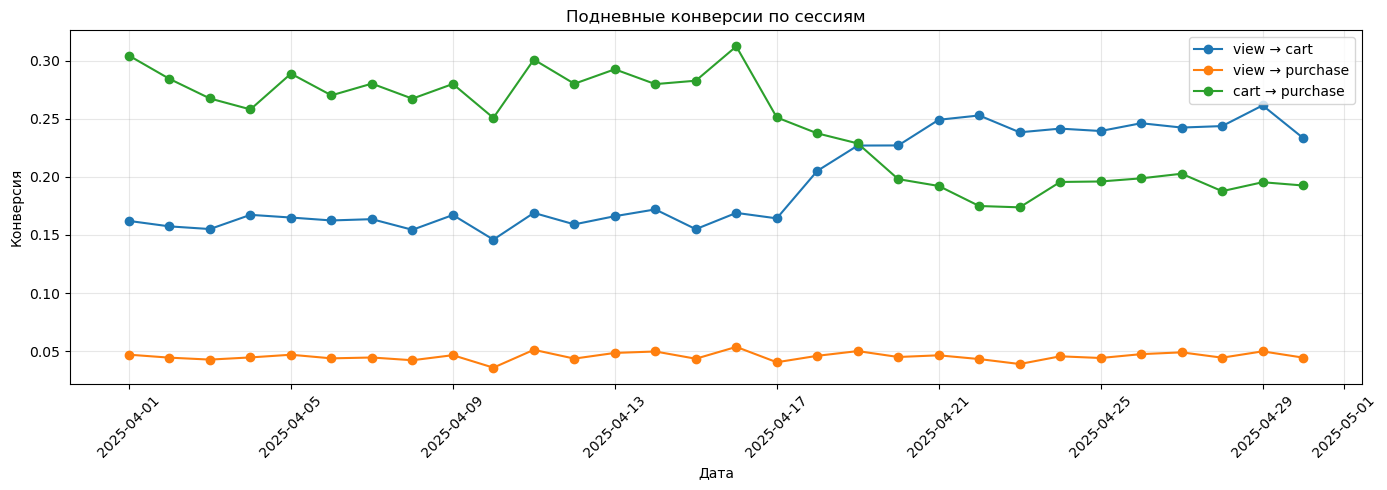

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(daily.index, daily['view_to_cart'], marker='o', label='view → cart')
plt.plot(daily.index, daily['view_to_purchase'], marker='o', label='view → purchase')
plt.plot(daily.index, daily['cart_to_purchase'], marker='o', label='cart → purchase')
plt.xlabel('Дата')
plt.ylabel('Конверсия')
plt.title('Подневные конверсии по сессиям')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Комментарии
По графику можно отследить, что чуть до 17 апреля началось сильное падение конверсии cart--> purchase с 0.30 до 0.19 (Падение +- в 1.5 раза). Паралельно этому падению в тех же 17-ых числах произошло увеличение другой метрики view --> cart с 0.16 до 0.24. Заключительная метрика (view --> purchase) была стабильна! 

Всё это указывает на то, что пользователи стали чаще добавлять наш продукт в корзину, но реже его заказывать, всё это произошло с +- 17 апреля. 


#### **2. Проверка абсолютных и средних значений — 1 балл**

1) Постройте графики дневной динамики абсолютных значений, из которых рассчитаны конверсии выше.
2) Рассчитайте и визуализируйте среднее число событий (именно событий, не сессий), из которых рассчитаны конверсии, на пользователя. 
3) На каком этапе воронки появилась проблема?

## Вначале абсолютные значения

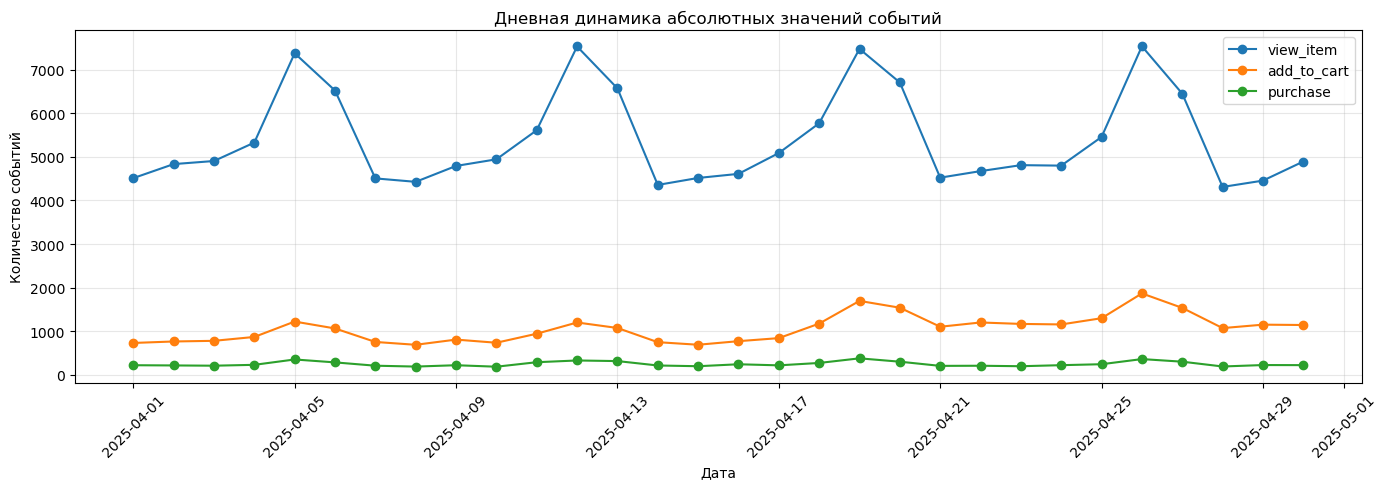

In [9]:
absolutes = df.groupby(['date', 'event']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 5))
for col in ['view_item', 'add_to_cart', 'purchase']:
    plt.plot(absolutes.index, absolutes[col], marker='o', label=col)
plt.xlabel('Дата')
plt.ylabel('Количество событий')
plt.title('Дневная динамика абсолютных значений событий')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Теперь авг на пользователя 

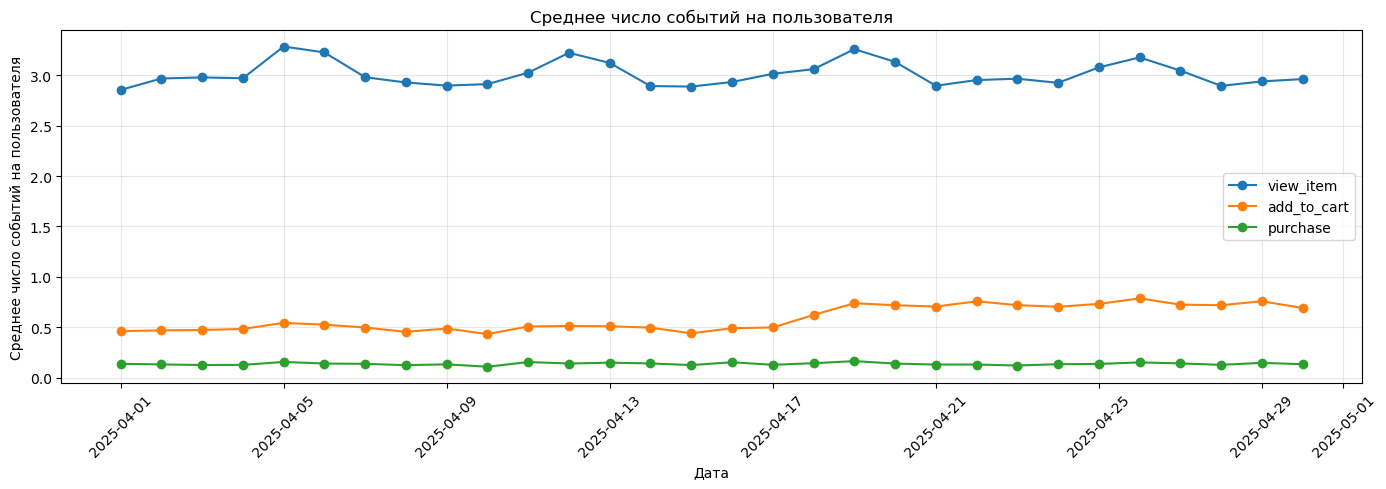

In [11]:
# your code is here
users_daily = df.groupby('date')['user_id'].nunique()
events_daily = df.groupby(['date', 'event']).size().unstack(fill_value=0)

avg_per_user = events_daily.div(users_daily, axis=0)

plt.figure(figsize=(14, 5))
for col in ['view_item', 'add_to_cart', 'purchase']:
    plt.plot(avg_per_user.index, avg_per_user[col], marker='o', label=col)
plt.xlabel('Дата')
plt.ylabel('Среднее число событий на пользователя')
plt.title('Среднее число событий на пользователя')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Комментарий
Проблематика прошлого задания подтвердается. У нас хорошо смотрят, замечательно добавляют в корзину, но самого заказа не происходит. Причем также с 17 числа идет увеличение среднего значения добавлений в корзину, а заказы остаются фиксой. 

#### **3. Базовые срезы — 1 балл**
1. Постройте динамику события, среднее значение которого подскочило, в разрезе:
- платформ,
- регионов,
- источников трафика,
- категорий товаров.

2. Есть ли выделяющийся срез?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

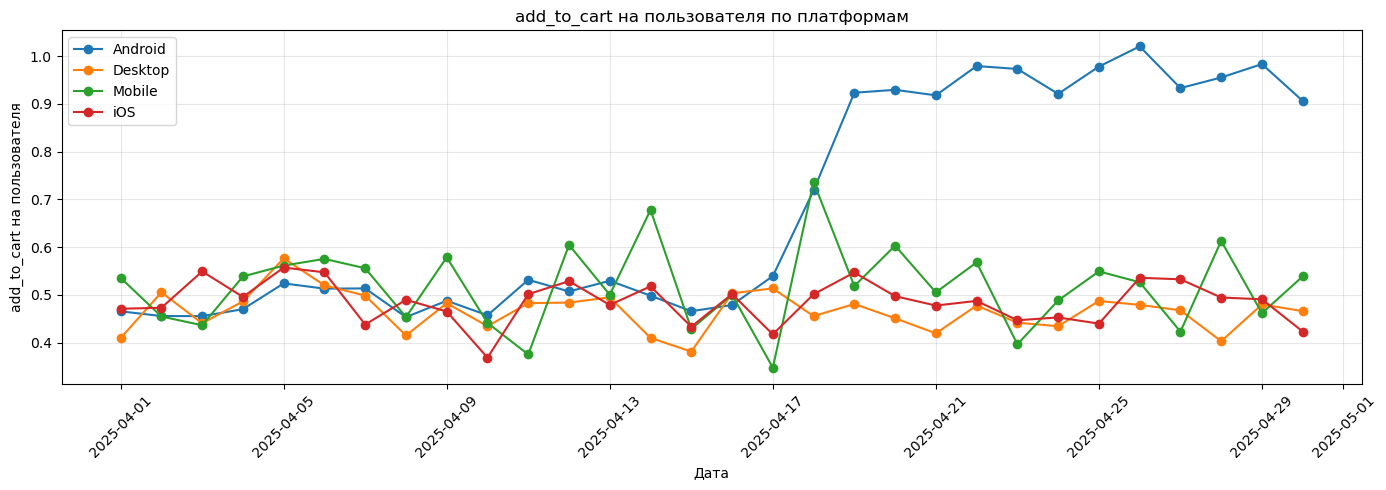

In [12]:
# your code is here
users_by = df.groupby(['date', 'platform'])['user_id'].nunique()
events_by = df[df['event'] == 'add_to_cart'].groupby(['date', 'platform']).size()

avg_platform = events_by / users_by
avg_platform = avg_platform.unstack(fill_value=0)

plt.figure(figsize=(14, 5))
for col in avg_platform.columns:
    plt.plot(avg_platform.index, avg_platform[col], marker='o', label=col)
plt.xlabel('Дата')
plt.ylabel('add_to_cart на пользователя')
plt.title('add_to_cart на пользователя по платформам')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

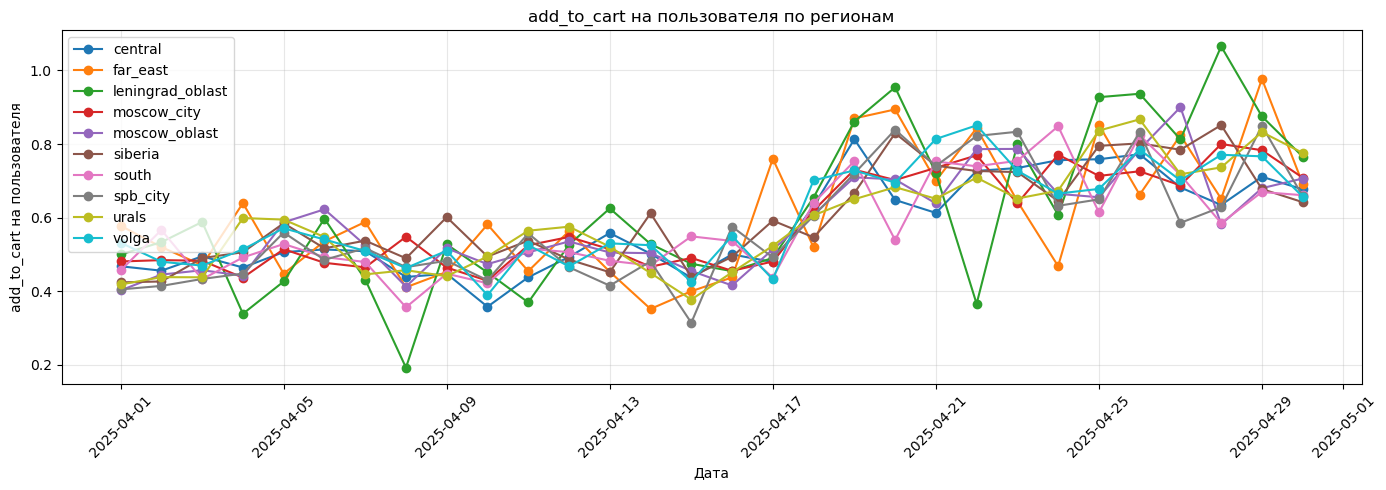

In [13]:
users_by = df.groupby(['date', 'region'])['user_id'].nunique()
events_by = df[df['event'] == 'add_to_cart'].groupby(['date', 'region']).size()

avg_region = events_by / users_by
avg_region = avg_region.unstack(fill_value=0)

plt.figure(figsize=(14, 5))
for col in avg_region.columns:
    plt.plot(avg_region.index, avg_region[col], marker='o', label=col)
plt.xlabel('Дата')
plt.ylabel('add_to_cart на пользователя')
plt.title('add_to_cart на пользователя по регионам')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

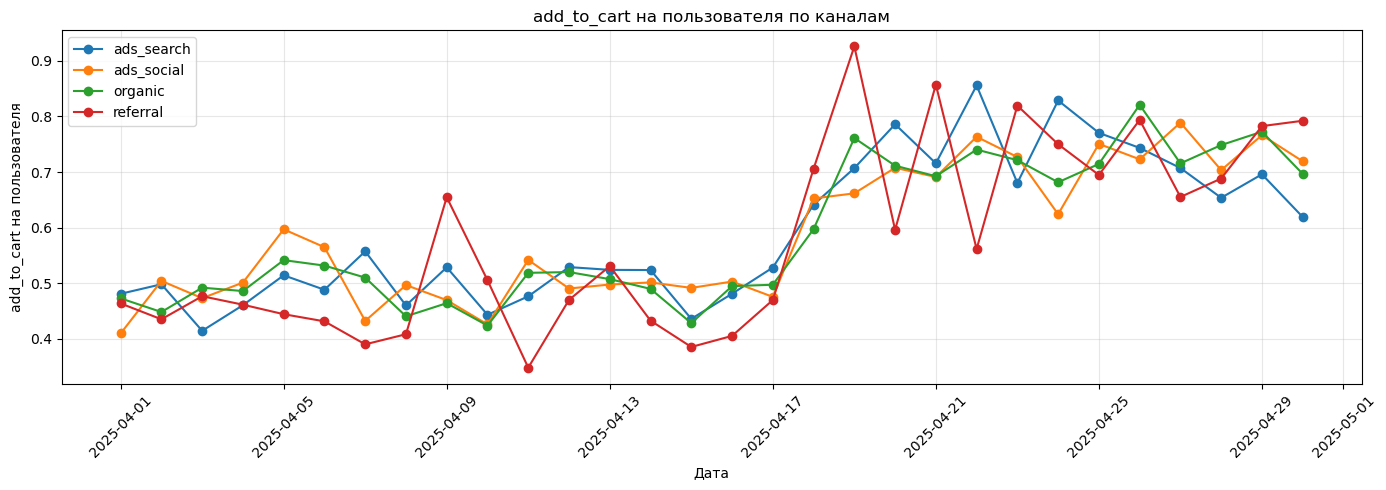

In [14]:
users_by = df.groupby(['date', 'channel'])['user_id'].nunique()
events_by = df[df['event'] == 'add_to_cart'].groupby(['date', 'channel']).size()

avg_channel = events_by / users_by
avg_channel = avg_channel.unstack(fill_value=0)

plt.figure(figsize=(14, 5))
for col in avg_channel.columns:
    plt.plot(avg_channel.index, avg_channel[col], marker='o', label=col)
plt.xlabel('Дата')
plt.ylabel('add_to_cart на пользователя')
plt.title('add_to_cart на пользователя по каналам')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

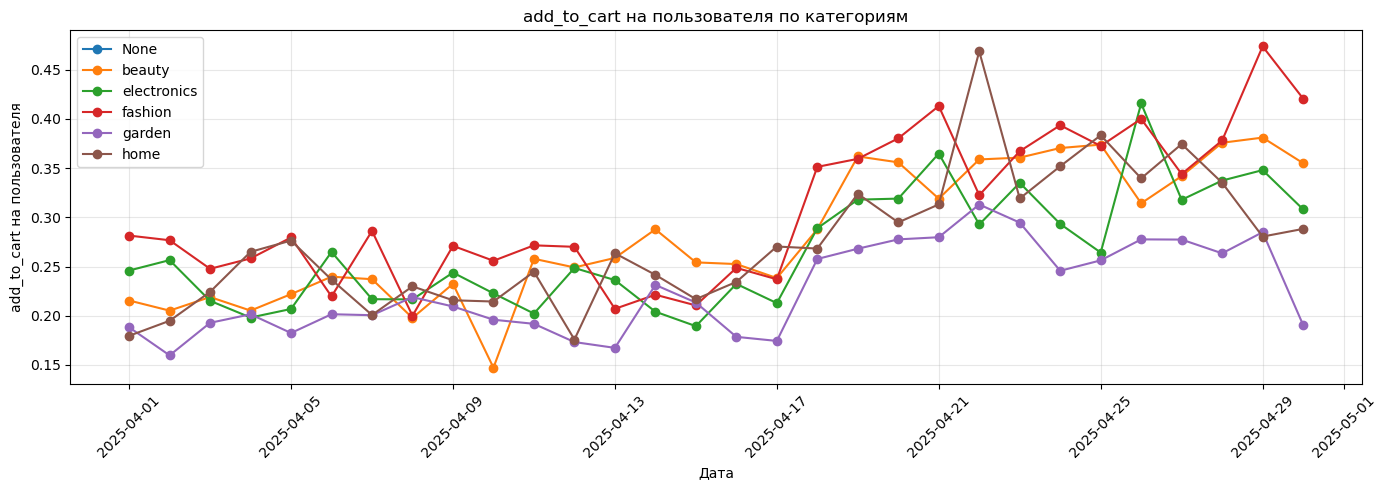

In [15]:
users_by = df.groupby(['date', 'category'])['user_id'].nunique()
events_by = df[df['event'] == 'add_to_cart'].groupby(['date', 'category']).size()

avg_cat = events_by / users_by
avg_cat = avg_cat.unstack(fill_value=0)

plt.figure(figsize=(14, 5))
for col in avg_cat.columns:
    plt.plot(avg_cat.index, avg_cat[col], marker='o', label=col)
plt.xlabel('Дата')
plt.ylabel('add_to_cart на пользователя')
plt.title('add_to_cart на пользователя по категориям')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Комментарий 
У нашей великой компании жесточайший всплеск пользователей андроида как раз с 17 апреля. Был бы я стримером на твиче, я бы сказал, что нам жестко накручивают, но в рамках компании нужно копать глубже, хотя тест/сабботаж, я бы не убирал :)))) 


#### **4. Детальные срезы — 1 балл**
1. Постройте динамику события для iOS и Android с разложением по версиям приложения.
2. Помогло ли это локализовать проблему?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

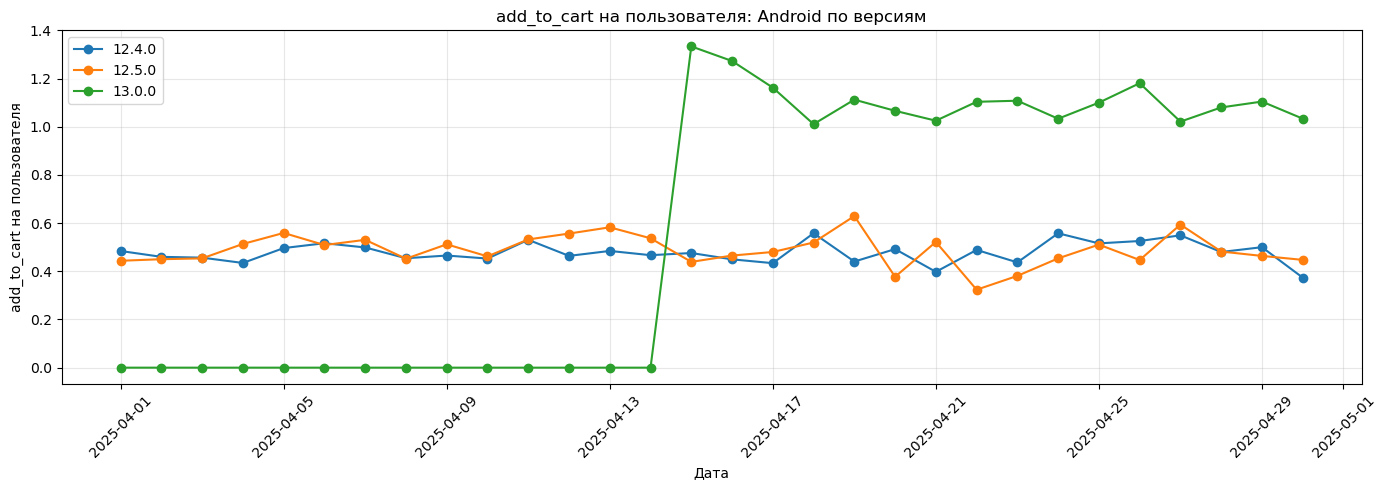

In [16]:
# your code is here
users_and = df[df['platform'] == 'Android'].groupby(['date', 'app_version'])['user_id'].nunique()
events_and = df[(df['event'] == 'add_to_cart') & (df['platform'] == 'Android')].groupby(['date', 'app_version']).size()

avg_and = events_and / users_and
avg_and = avg_and.unstack(fill_value=0)

plt.figure(figsize=(14, 5))
for col in avg_and.columns:
    plt.plot(avg_and.index, avg_and[col], marker='o', label=col)
plt.xlabel('Дата')
plt.ylabel('add_to_cart на пользователя')
plt.title('add_to_cart на пользователя: Android по версиям')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

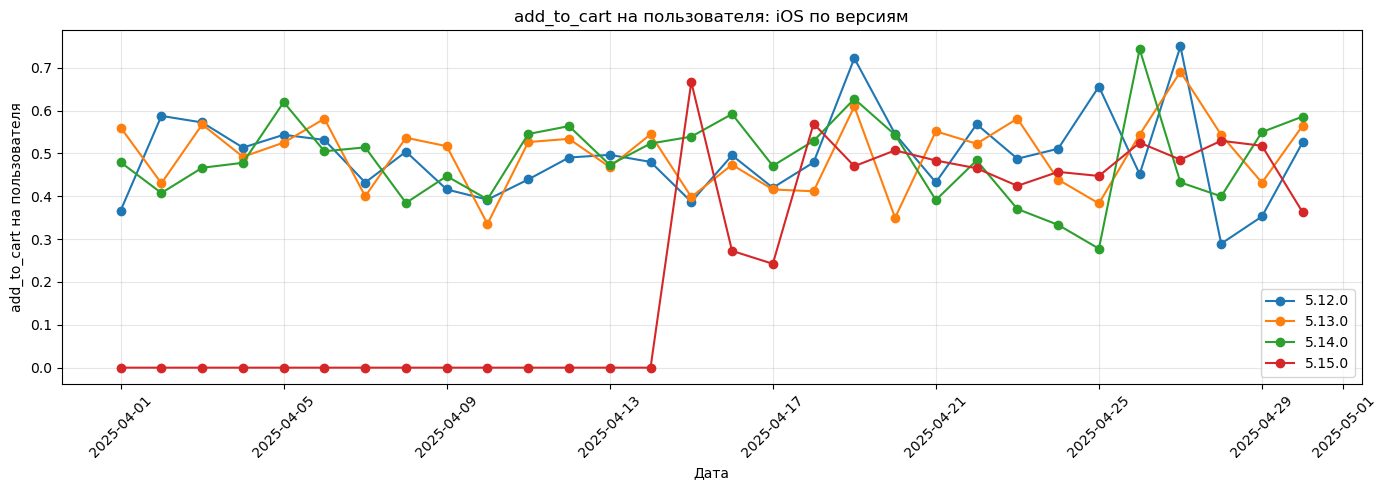

In [17]:
users_ios = df[df['platform'] == 'iOS'].groupby(['date', 'app_version'])['user_id'].nunique()
events_ios = df[(df['event'] == 'add_to_cart') & (df['platform'] == 'iOS')].groupby(['date', 'app_version']).size()

avg_ios = events_ios / users_ios
avg_ios = avg_ios.unstack(fill_value=0)

plt.figure(figsize=(14, 5))
for col in avg_ios.columns:
    plt.plot(avg_ios.index, avg_ios[col], marker='o', label=col)
plt.xlabel('Дата')
plt.ylabel('add_to_cart на пользователя')
plt.title('add_to_cart на пользователя: iOS по версиям')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Комментарий
Все те же проблемы, только тут, мы еще сумели локализовать очаг всплеска на 2-ух новых версихя IOS и дроида, с выходом версий 5.15.0 и 13.0.0 соответственно началась наша вакханалия


#### **5. Поиск причин — 1 балл**
1. Для проблемной платформы постройте динамику ВСЕХ событий в разрезе версий приложения.
2. Сформулируйте гипотезу, что именно могло пойти не так в новом релизе? Может быть, пользователи стали заменять один функционал другим?

*В этом пункте в качестве событий продолжаем смотреть метрику среднего на пользователя*

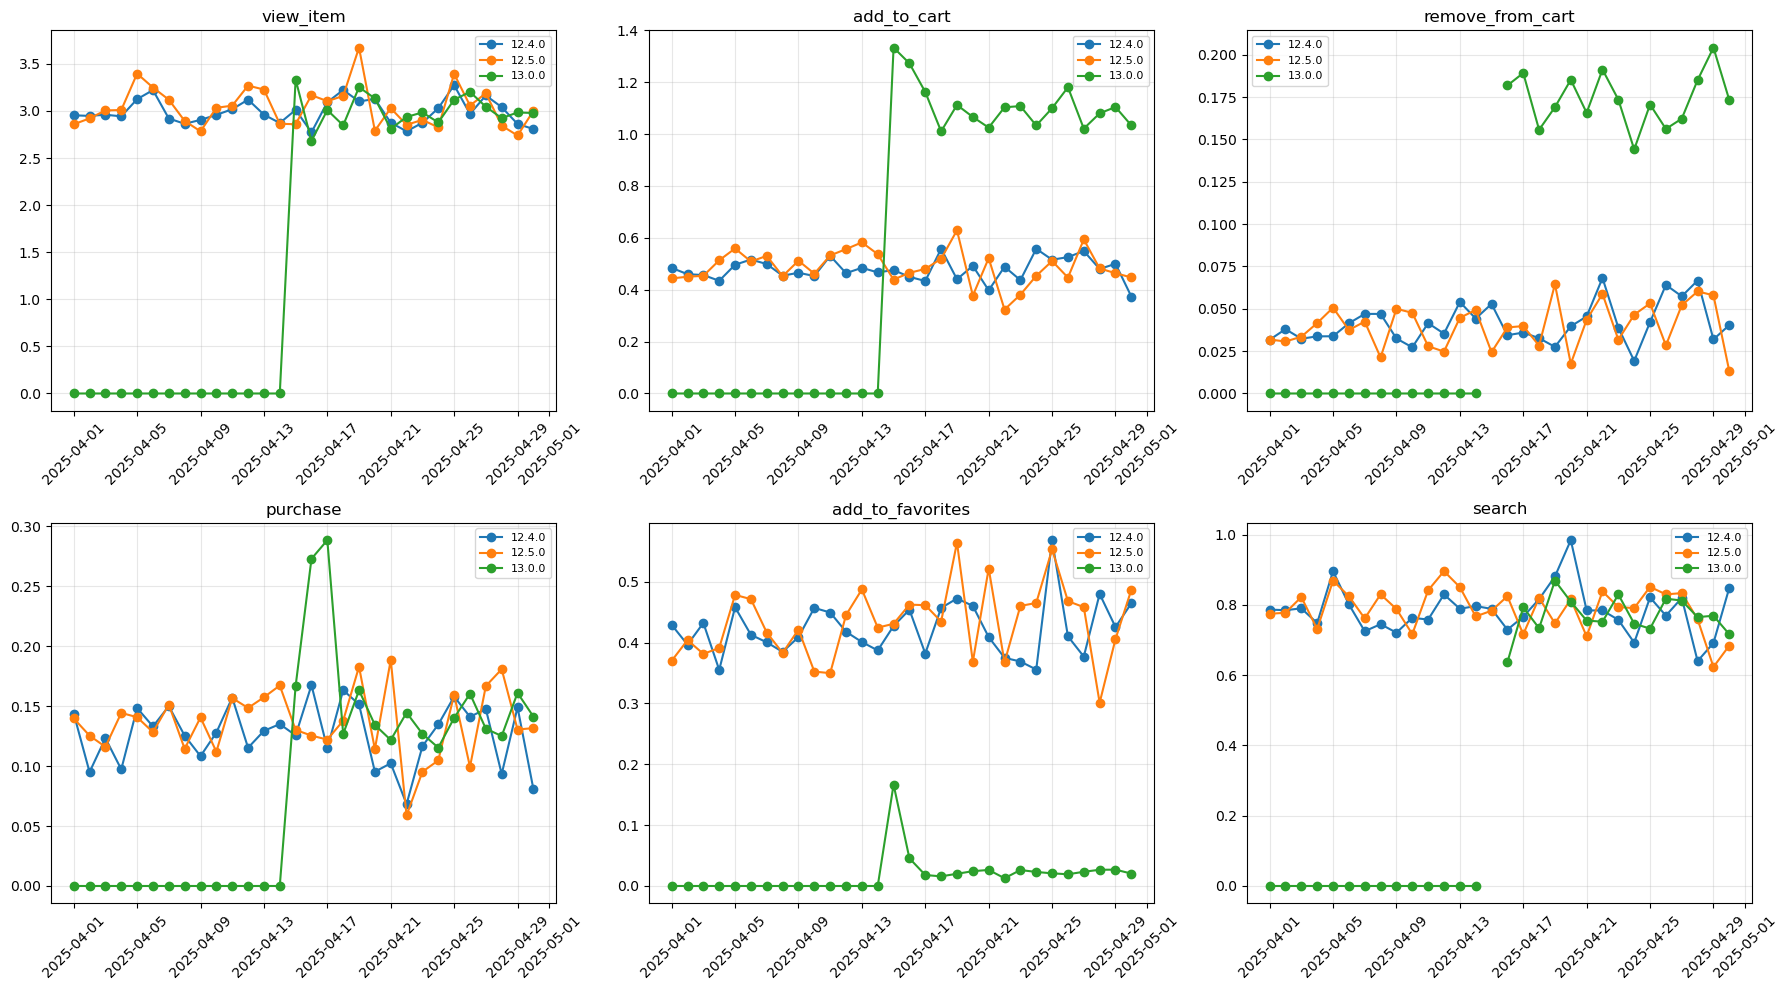

In [18]:
# your code is here
events_list = ['view_item', 'add_to_cart', 'remove_from_cart', 'purchase', 'add_to_favorites', 'search']

users_and = df[df['platform'] == 'Android'].groupby(['date', 'app_version'])['user_id'].nunique()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, ev in enumerate(events_list):
    events_and = df[(df['event'] == ev) & (df['platform'] == 'Android')].groupby(['date', 'app_version']).size()
    avg_and = events_and / users_and
    avg_and = avg_and.unstack(fill_value=0)
    
    for col in avg_and.columns:
        axes[i].plot(avg_and.index, avg_and[col], marker='o', label=col)
    axes[i].set_title(ev)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Комментарий
Всё, что было ранее сохраняется, вышла новая версия произошел какой-то апокалипсис добавления в корзину. Вероятнее всего какой-то тех. баг на новой версии. 

#### **6. Новости для команды — 1 балл**

На основе проведённого расследования подготовьте сообщение для команды о том, что именно пошло не так.

Уважаемая команда! :)))) (Нет)

Вы сделали кривую версию приложения, срочно откатите версию, иначе  генеральный нас убьёт за снижение показателей :))))))))

Сделайте хот фикс прилдожения, проверьте кнопочку добавления в корзину на мобильных версихя приложения :)))))

Иначе вас уволят :))))

И меня :))))

Усё